<a href="https://colab.research.google.com/github/mikysetiawan/CoreModuleMealApps/blob/main/Tugas_1_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import Lib

In [58]:
!pip install pipreqs
!pip install sastrawi
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.5 MB/s eta 0:00:00


In [59]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining

import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

import csv
import requests
from io import StringIO

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from gensim.models import Word2Vec

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt_tab')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Load data from csv and load to pandas

In [3]:
# Load data dari csv ulasan_aplikasi.csv
datas = pd.read_csv('ulasan_aplikasi.csv')

# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.DataFrame(datas)

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,189993c1-d607-4d21-8758-3400c72ee7ce,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,banyak driver pada males jemput. rata² semua d...,1,4,5.56.2,2026-04-19 13:19:11,"Hai Kak Jihan, mohon maaf atas ketidaknyamanan...",2026-04-19 14:03:45,5.56.2
1,1b70120d-9109-4727-81ed-b4daa5aee58c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Game baru Bolak Balok banyak bug, peningkatan ...",3,2,5.57.2,2026-04-29 07:59:55,"Hai Kak Nanang, mohon maaf atas kendalanya. Pa...",2026-04-29 08:42:32,5.57.2
2,fa42d47a-8dc0-465d-bcdf-6efb76536caa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa saya nggak bisa main bolak-balok lagi s...,1,2,5.57.2,2026-04-29 21:21:21,"Hai Kak Rivaldi, mohon maaf atas ketidaknyaman...",2026-04-29 21:34:03,5.57.2
3,3aea3e6c-6756-474d-aa21-469a15d3af89,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gajelas ni makin ksini, di kasih taunya tingga...",3,5,5.55.2,2026-04-14 07:13:13,"Hai Kak Alscha, mohon maaf atas ketidaknyamana...",2026-04-14 08:40:57,5.55.2
4,09a3049c-e8dc-42a5-b627-4855e979a441,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tambah menurun ...biasa klu sdh dikenal pasti ...,1,3,5.57.2,2026-04-27 18:40:12,"Hai Kak Anik, mohon maaf atas ketidaknyamanann...",2026-03-17 21:19:12,5.57.2


In [4]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10000 non-null  object
 1   userName              10000 non-null  object
 2   userImage             10000 non-null  object
 3   content               10000 non-null  object
 4   score                 10000 non-null  int64 
 5   thumbsUpCount         10000 non-null  int64 
 6   reviewCreatedVersion  8331 non-null   object
 7   at                    10000 non-null  object
 8   replyContent          5803 non-null   object
 9   repliedAt             5803 non-null   object
 10  appVersion            8331 non-null   object
dtypes: int64(2), object(9)
memory usage: 859.5+ KB


In [5]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna()

In [6]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4787 entries, 0 to 9996
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              4787 non-null   object
 1   userName              4787 non-null   object
 2   userImage             4787 non-null   object
 3   content               4787 non-null   object
 4   score                 4787 non-null   int64 
 5   thumbsUpCount         4787 non-null   int64 
 6   reviewCreatedVersion  4787 non-null   object
 7   at                    4787 non-null   object
 8   replyContent          4787 non-null   object
 9   repliedAt             4787 non-null   object
 10  appVersion            4787 non-null   object
dtypes: int64(2), object(9)
memory usage: 448.8+ KB


**Preprocessing Text**

In [7]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [34]:
slangwords = {
    "@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar",
    "bgt": "banget", "maks": "maksimal", "min": "minimal", "teros": "terus", "krn": "karena",
    "yg": "yang", "gk": "tidak", "kalo": "kalau", "udah": "sudah", "aja": "saja", "tau": "tahu",
    "tp": "tapi", "rb": "ribu", "pake": "pakai", "tdk": "tidak", "pa": "apa", "app": "aplikasi",
    "gitu": "begitu", "gabisa": "tidak bisa", "klo": "kalau", "nggak": "tidak", "ngga": "tidak", "banget": "sangat",
    "udh": "sudah", "tetep": "tetap", "jg": "juga", "nunggu": "menunggu", "jd": "jadi"
    }
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text


In [35]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity
0,189993c1-d607-4d21-8758-3400c72ee7ce,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,banyak driver pada males jemput. rata² semua d...,1,4,5.56.2,2026-04-19 13:19:11,"Hai Kak Jihan, mohon maaf atas ketidaknyamanan...",2026-04-19 14:03:45,5.56.2,banyak driver pada males jemput rata² semua dr...,banyak driver pada males jemput rata² semua dr...,banyak driver pada males jemput rata² semua dr...,"[banyak, driver, pada, males, jemput, rata², s...","[driver, males, jemput, rata², driver, chat, p...",driver males jemput rata² driver chat pesan pi...,14,positive
1,1b70120d-9109-4727-81ed-b4daa5aee58c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Game baru Bolak Balok banyak bug, peningkatan ...",3,2,5.57.2,2026-04-29 07:59:55,"Hai Kak Nanang, mohon maaf atas kendalanya. Pa...",2026-04-29 08:42:32,5.57.2,Game baru Bolak Balok banyak bug peningkatan d...,game baru bolak balok banyak bug peningkatan d...,game baru bolak balok banyak bug peningkatan d...,"[game, baru, bolak, balok, banyak, bug, pening...","[game, bolak, balok, bug, peningkatan, difficu...",game bolak balok bug peningkatan difficulty ng...,7,positive
2,fa42d47a-8dc0-465d-bcdf-6efb76536caa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa saya nggak bisa main bolak-balok lagi s...,1,2,5.57.2,2026-04-29 21:21:21,"Hai Kak Rivaldi, mohon maaf atas ketidaknyaman...",2026-04-29 21:34:03,5.57.2,Kenapa saya nggak bisa main bolakbalok lagi se...,kenapa saya nggak bisa main bolakbalok lagi se...,kenapa saya tidak bisa main bolakbalok lagi se...,"[kenapa, saya, tidak, bisa, main, bolakbalok, ...","[main, bolakbalok, mencapai, poin, dinyatakan,...",main bolakbalok mencapai poin dinyatakan aktiv...,-12,negative
3,3aea3e6c-6756-474d-aa21-469a15d3af89,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gajelas ni makin ksini, di kasih taunya tingga...",3,5,5.55.2,2026-04-14 07:13:13,"Hai Kak Alscha, mohon maaf atas ketidaknyamana...",2026-04-14 08:40:57,5.55.2,gajelas ni makin ksini di kasih taunya tinggal...,gajelas ni makin ksini di kasih taunya tinggal...,gajelas ni makin ksini di kasih taunya tinggal...,"[gajelas, ni, makin, ksini, di, kasih, taunya,...","[gajelas, ni, ksini, kasih, taunya, tinggal, m...",gajelas ni ksini kasih taunya tinggal menit ja...,1,positive
4,09a3049c-e8dc-42a5-b627-4855e979a441,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tambah menurun ...biasa klu sdh dikenal pasti ...,1,3,5.57.2,2026-04-27 18:40:12,"Hai Kak Anik, mohon maaf atas ketidaknyamanann...",2026-03-17 21:19:12,5.57.2,tambah menurun biasa klu sdh dikenal pasti kua...,tambah menurun biasa klu sdh dikenal pasti kua...,tambah menurun biasa klu sdh dikenal pasti kua...,"[tambah, menurun, biasa, klu, sdh, dikenal, pa...","[menurun, klu, sdh, dikenal, kualitas, menurun...",menurun klu sdh dikenal kualitas menurun beda ...,6,positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,802e4d25-13f1-44e6-95a3-e36264b98c34,Agung Muhamad,https://play-lh.googleusercontent.com/a-/ALV-U...,"Ketika update gopay plus, nama di profil langs...",1,184,4.38.2,2022-03-05 14:38:24,"Hai Agung Muhamad, mohon maaf untuk kendalanya...",2022-03-06 09:09:34,4.38.2,Ketika update gopay plus nama di profil langsu...,ketika update gopay plus nama di profil langsu...,ketika update gopay plus nama di profil langsu...,"[ketika, update, gopay, plus, nama, di, profil...","[update, gopay, plus, nama, profil, langsung, ...",update gopay plus nama profil langsung nama go...,9,positive
9992,01803659-d12a-4d37-b46c-e8252197b6d3,liau shu fun,https://play-lh.googleusercontent.com/a/ACg8oc...,"Driver gojek tidak pernah berubah, mau menerim...",1,0,4.81.1,2024-04-30 08:27:43,"Hai Kak

**Pelabelan**

In [22]:
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [38]:
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    # Inisialisasi skor sentimen ke 0
    score = 0

    # simpan text positif dan negatif
    text_positive = []
    text_negative = []

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
          # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen
            score = score + lexicon_positive[word]
            text_positive.append(word)

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen
            score = score + lexicon_negative[word]
            text_negative.append(word)

    # Inisialisasi variabel polaritas
    polarity=''

    if (score >= 0):
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
        polarity = 'positive'
    elif (score < 0):
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif
        polarity = 'negative'
    else:
        # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan
        polarity = 'neutral'

    # Mengembalikan skor sentimen dan polaritas teks
    return score, polarity, text_positive, text_negative

In [44]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
text_positive = results[2]
text_negative = results[3]

# flatten kumpulan teks, karena bentuknya masih nested array
flat_positive = [word for sublist in text_positive for word in sublist]
flat_negative = [word for sublist in text_negative for word in sublist]

print(clean_df['polarity'].value_counts())

polarity
negative    3273
positive    1514
Name: count, dtype: int64


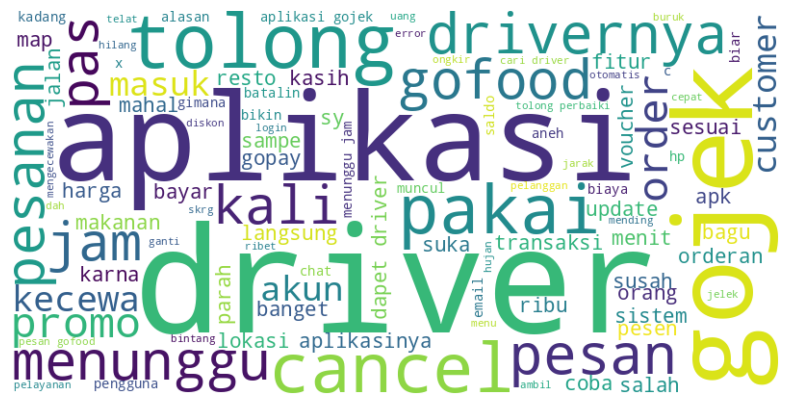

In [40]:
# Tampilkan pada word cloud
text = " ".join(clean_df['text_akhir'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis', # Warna visual
    max_words=100
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Sembunyikan sumbu X dan Y
plt.show()

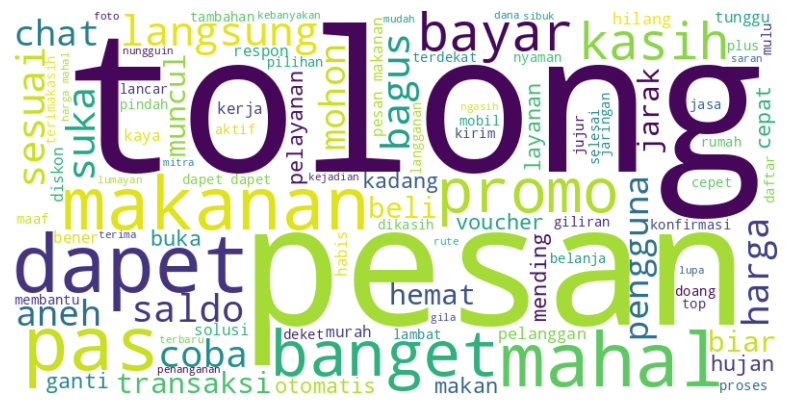

In [45]:
# Tampilkan pada word cloud untuk kata positif
text = " ".join(flat_positive)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis', # Warna visual
    max_words=100
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Sembunyikan sumbu X dan Y
plt.show()

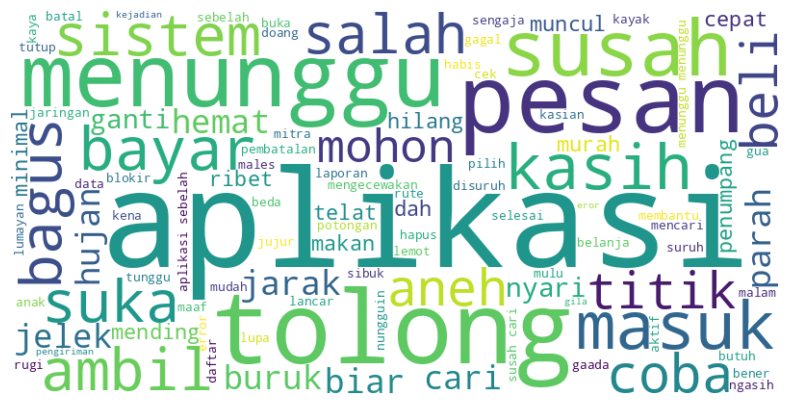

In [47]:
# Tampilkan pada word cloud untuk kata negatif
text = " ".join(flat_negative)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis', # Warna visual
    max_words=100
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Sembunyikan sumbu X dan Y
plt.show()

**Data Splitting - TF-IDF**

In [92]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(
    max_features=3000,
    min_df=5, # Remove kata yang muncul < 5 kali
    max_df=0.9, # Mengabaikan kata yang umum (90% ada di result)
    ngram_range=(1, 2),   # Gunakan Unigram & Bigram (menangkap kata seperti "tidak enak")
)
X_tfidf = tfidf.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

# Bagi data menjadi data latih dan data uji
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

**Data Splitting - Word2Vec**

In [62]:
# Word2Vec butuh input berupa list dari kata-kata (tokenized)
# Kita pecah setiap kalimat di clean_df['text_akhir'] menjadi list kata
sentences = [str(text).split() for text in clean_df['text_akhir']]

# Latih model Word2Vec
w2v_model = Word2Vec(sentences, vector_size=1000, window=5, min_count=1, workers=4)

def get_sentence_vector(sentence, model):
    words = str(sentence).split()
    # Ambil vektor untuk setiap kata jika kata tersebut ada dalam kamus Word2Vec
    word_vectors = [model.wv[word] for word in words if word in model.wv]

    if len(word_vectors) > 0:
        return np.mean(word_vectors, axis=0) # Rata-rata vektor
    else:
        return np.zeros(model.vector_size) # Jika tidak ada kata yang dikenal

# Terapkan fungsi ke semua data
X_w2v = np.array([get_sentence_vector(s, w2v_model) for s in clean_df['text_akhir']])

# Bagi data 80/20 sesuai skema percobaan Anda
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

**Modelling - Naive Bayes - TF-IDF**

In [80]:
# Membuat objek model Naive Bayes (Bernoulli Naive Bayes)
naive_bayes = BernoulliNB()

# Melatih model Naive Bayes pada data pelatihan
naive_bayes.fit(X_train_tfidf.toarray(), y_train_tfidf)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = naive_bayes.predict(X_train_tfidf.toarray())
y_pred_test_nb = naive_bayes.predict(X_test_tfidf.toarray())

# Evaluasi akurasi model Naive Bayes
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train_tfidf)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test_tfidf)

# Menampilkan akurasi
print('Naive Bayes + TF-IDF - accuracy_train:', accuracy_train_nb)
print('Naive Bayes + TF-IDF - accuracy_test:', accuracy_test_nb)

Naive Bayes + TF-IDF - accuracy_train: 0.8717680856620528
Naive Bayes + TF-IDF - accuracy_test: 0.7839248434237995


**Modelling - Random Forest - TF-IDF**

In [93]:
# Membuat objek model Random Forest
rf_tfidf = RandomForestClassifier(
    n_estimators=500,
    max_depth=50,
    random_state=42,
    class_weight='balanced'
)

# Melatih model Random Forest pada data pelatihan
rf_tfidf.fit(X_train_tfidf.toarray(), y_train_tfidf)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = rf_tfidf.predict(X_train_tfidf.toarray())
y_pred_test_rf = rf_tfidf.predict(X_test_tfidf.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train_tfidf)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test_tfidf)

# Menampilkan akurasi
print('Random Forest + TF-IDF - accuracy_train:', accuracy_train_rf)
print('Random Forest + TF-IDF - accuracy_test:', accuracy_test_rf)

Random Forest + TF-IDF - accuracy_train: 0.9916427265604596
Random Forest + TF-IDF - accuracy_test: 0.837160751565762


**Modelling - Random Forest - W2V**

In [67]:
# Latih Random Forest
rf_w2v = RandomForestClassifier(
    n_estimators=100,   # Jumlah pohon
    max_depth=10,       # Batasi kedalaman pohon agar tidak terlalu hafal data (mencegah overfitting)
    random_state=42
)
rf_w2v.fit(X_train_w2v, y_train_w2v)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf_w2v = rf_w2v.predict(X_train_w2v)
y_pred_test_rf_w2v = rf_w2v.predict(X_test_w2v)

# Evaluasi akurasi model Random Forest
accuracy_train_rf_w2v = accuracy_score(y_pred_train_rf_w2v, y_train_w2v)
accuracy_test_rf_w2v = accuracy_score(y_pred_test_rf_w2v, y_test_w2v)

# Menampilkan akurasi
print('Random Forest + W2V - accuracy_train:', accuracy_train_rf_w2v)
print('Random Forest + W2V - accuracy_test:', accuracy_test_rf_w2v)

Random Forest + W2V - accuracy_train: 0.8028205797858449
Random Forest + W2V - accuracy_test: 0.7192066805845512


**Modelling - SVM - TF-IDF**

In [ ]:
# Gunakan kernel RBF atau Linear
model_svm = SVC(kernel='linear', C=1.0, probability=True)
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)
print("Akurasi SVM:", accuracy_score(y_test, y_pred_svm))